## Bibliothèques

In [117]:
%pip install xgboost
%pip install lightgbm
%pip install catboost

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Conversion rate challenge

In [118]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "notebook" # to be replaced by "iframe" if working on JULIE
from IPython.display import display

## Exploration des données

In [119]:
# Lecture des fichiers
print("Loading dataset...")
dataset = pd.read_csv("D:/Profils/NLefort/Desktop/JEDHA/PROJETS/05.ML_supervise/Rate_challenge/conversion_data_train.csv")
print("...Done.")

Loading dataset...
...Done.


In [120]:
## Analyse descriptive
# INFORMATIONS GENERALES
print("\n INFORMATIONS GENERALES")
print("-"*40)

print("Nombre de lignes : {}".format(dataset.shape[0]))
print("Nombre de colonnes : {}".format(dataset.shape[1]))

print("Aperçu du dataset : ")
display(dataset.head())

print("Types de données/colonnes : ")
display(dataset.dtypes)



 INFORMATIONS GENERALES
----------------------------------------
Nombre de lignes : 284580
Nombre de colonnes : 6
Aperçu du dataset : 


,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


Types de données/colonnes : 


country                object
age                     int64
new_user                int64
source                 object
total_pages_visited     int64
converted               int64
dtype: object

In [121]:
# VALEURS MANQUANTES
print(f"Nombre de valeurs manquantes par colonne : \n{dataset.isnull().sum()}")


Nombre de valeurs manquantes par colonne : 
country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
converted              0
dtype: int64


In [122]:
# STATISTIQUES DESCRIPTIVES
# Statistiques descriptives globales
print("Statistiques descriptives globales :")
display(dataset.describe(include="all").round(2))

Statistiques descriptives globales :


,country,age,new_user,source,total_pages_visited,converted
count,284580,284580.00,284580.00,284580,284580.00,284580.00
unique,4,NaN,NaN,3,NaN,NaN
top,US,NaN,NaN,Seo,NaN,NaN
freq,160124,NaN,NaN,139477,NaN,NaN
mean,NaN,30.56,0.69,NaN,4.87,0.03
std,NaN,8.27,0.46,NaN,3.34,0.18
min,NaN,17.00,0.00,NaN,1.00,0.00
25%,NaN,24.00,0.00,NaN,2.00,0.00
50%,NaN,30.00,1.00,NaN,4.00,0.00
75%,NaN,36.00,1.00,NaN,7.00,0.00


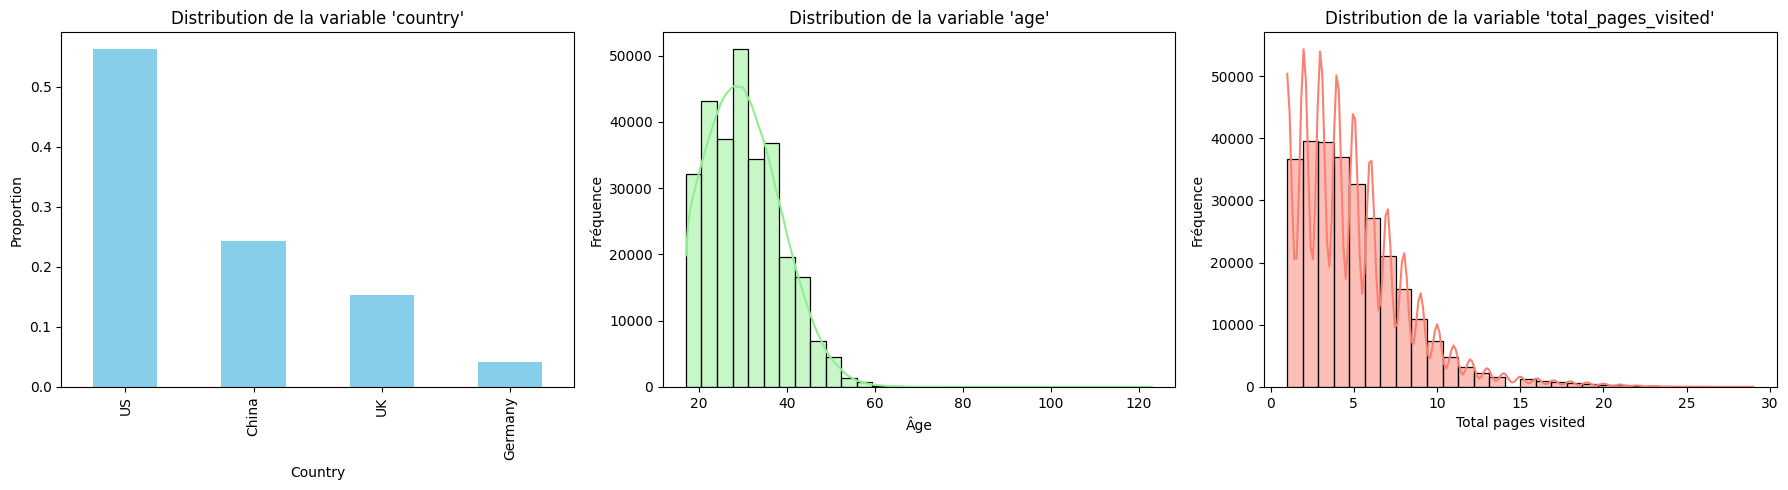

In [123]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Variable "country"
dataset['country'].value_counts(normalize=True).plot.bar(ax=axes[0], color='skyblue')
axes[0].set_title("Distribution de la variable 'country'")
axes[0].set_ylabel("Proportion")
axes[0].set_xlabel("Country")

# Variable "age"
sns.histplot(dataset['age'].dropna(), bins=30, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title("Distribution de la variable 'age'")
axes[1].set_xlabel("Âge")
axes[1].set_ylabel("Fréquence")

# Variable "total_pages_visited"
sns.histplot(dataset['total_pages_visited'].dropna(), bins=30, kde=True, ax=axes[2], color='salmon')
axes[2].set_title("Distribution de la variable 'total_pages_visited'")
axes[2].set_xlabel("Total pages visited")
axes[2].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

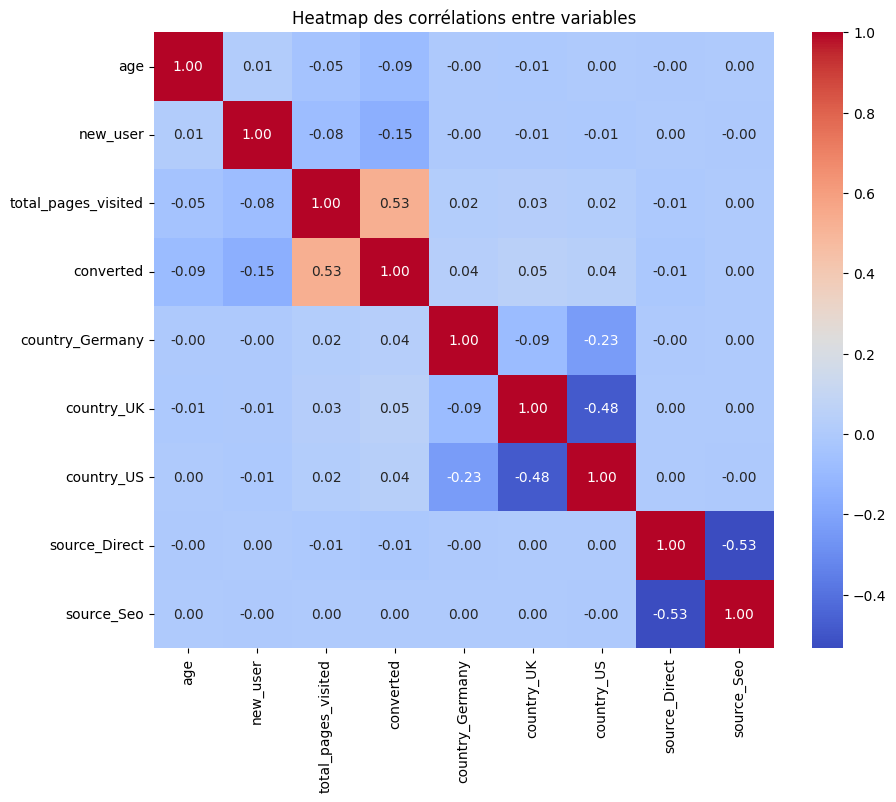

In [124]:
# HEATMAP globale
# Calcul de la matrice de corrélation
dataset_encoded = pd.get_dummies(dataset, drop_first=True)
corr = dataset_encoded.corr()

# Affichage de la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap des corrélations entre variables")
plt.show()

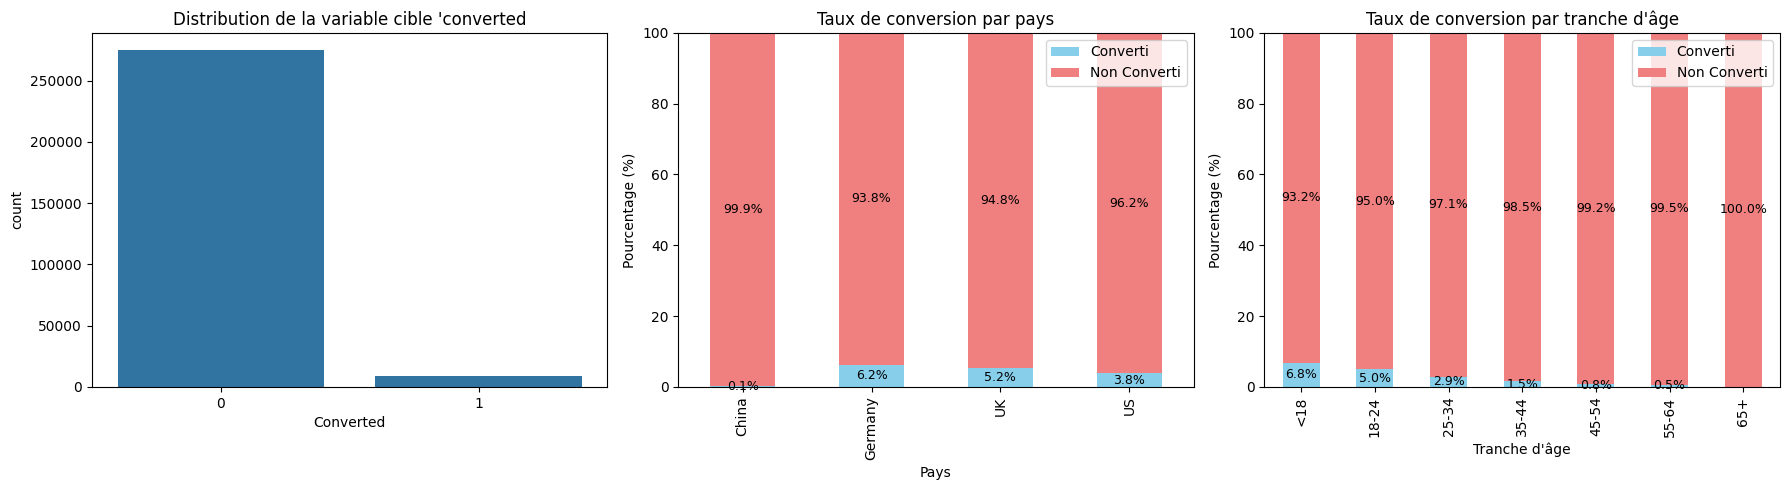

Taux de conversion (en pourcentage) : 3.23 %


In [125]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Countplot Converted
sns.countplot(x='converted', data=dataset, ax=axes[0])
axes[0].set_title("Distribution de la variable cible 'converted")
axes[0].set_xlabel("Converted")
axes[0].set_ylabel("count")

# Taux de conversion par pays
conversion_par_pays = pd.crosstab(dataset['country'], dataset['converted'], normalize='index') * 100
conversion_par_pays.columns = ['Non Converti', 'Converti']
conversion_par_pays = conversion_par_pays[['Converti', 'Non Converti']]

conversion_par_pays.plot(kind='bar', stacked=True, ax=axes[1], color=['skyblue', 'lightcoral'])
axes[1].set_ylabel("Pourcentage (%)")
axes[1].set_xlabel("Pays")
axes[1].set_title("Taux de conversion par pays")
axes[1].legend(title="", loc="upper right")
axes[1].set_ylim(0, 100)

# Ajouter les valeurs
for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].text(p.get_x() + p.get_width()/2, p.get_y() + p.get_height()/2,
                     f'{p.get_height():.1f}%', ha='center', va='center', fontsize=9)

# Taux de conversion par tranche d'âge
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18','18-24','25-34','35-44','45-54','55-64','65+']
dataset['age_group'] = pd.cut(dataset['age'], bins=bins, labels=labels)

conversion_par_age = pd.crosstab(dataset['age_group'], dataset['converted'], normalize='index') * 100
conversion_par_age.columns = ['Non Converti', 'Converti']
conversion_par_age = conversion_par_age[['Converti', 'Non Converti']]

conversion_par_age.plot(kind='bar', stacked=True, ax=axes[2], color=['skyblue', 'lightcoral'])
axes[2].set_ylabel("Pourcentage (%)")
axes[2].set_xlabel("Tranche d'âge")
axes[2].set_title("Taux de conversion par tranche d'âge")
axes[2].legend(title="", loc="upper right")
axes[2].set_ylim(0, 100)

# Ajouter les valeurs
for p in axes[2].patches:
    if p.get_height() > 0:
        axes[2].text(p.get_x() + p.get_width()/2, p.get_y() + p.get_height()/2,
                     f'{p.get_height():.1f}%', ha='center', va='center', fontsize=9)

# Ajustement
plt.tight_layout()
plt.show()

# Taux de conversion
taux_conversion = (dataset["converted"].mean() * 100).round(2)
print(f"Taux de conversion (en pourcentage) : {taux_conversion} %")

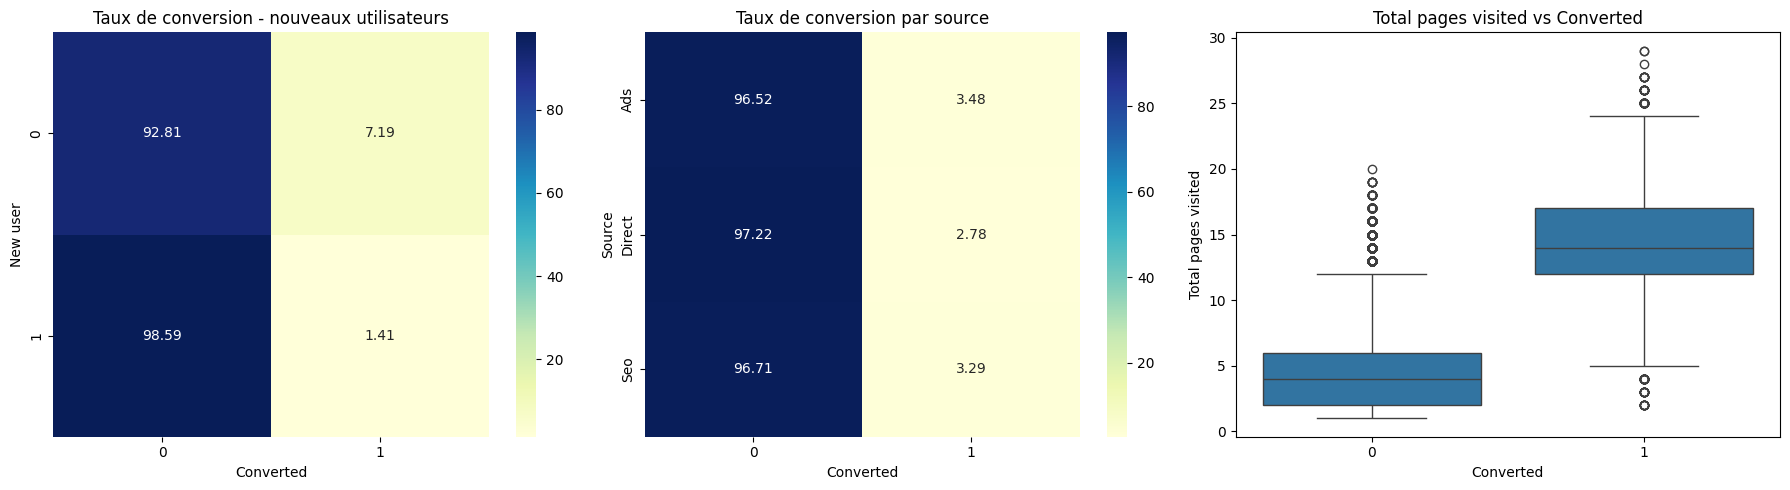

In [126]:
# Crosstab pour new_user
new_user = pd.crosstab(dataset['new_user'], dataset['converted'], normalize='index') * 100

# Crosstab pour source
source = pd.crosstab(dataset['source'], dataset['converted'], normalize='index') * 100

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Heatmap new_user
sns.heatmap(new_user, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Taux de conversion - nouveaux utilisateurs")
axes[0].set_ylabel("New user")
axes[0].set_xlabel("Converted")

# Heatmap source (seo = référence naturelle, ads = publicité, direct = accès direct)
sns.heatmap(source, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Taux de conversion par source")
axes[1].set_ylabel("Source")
axes[1].set_xlabel("Converted")

# Boxplot Total pages vs Converted
sns.boxplot(x='converted', y='total_pages_visited', data=dataset, ax=axes[2])
axes[2].set_title("Total pages visited vs Converted")
axes[2].set_xlabel("Converted")
axes[2].set_ylabel("Total pages visited")

plt.tight_layout()
plt.show()

### Synthèse
- 3.23 % d'abonnements sur le nombre de connexions
- Profil des utlisateurs : 30 ans en moyenne, 56 % des USA
- Habitudes de navigation : visite 4 pages en moyenne

Conversion en abonnement
- Plus de conversion en Allemagne que dans les autres pays
- Les utilisateurs qui s'abonnent ne sont pas nécessairement des nouveaux utilisateurs
- Les moins de 18 ans s'abonnent plus que les autres catégories d'âge
- Plus un utilisateur visite de pages, plus il a de chances de convertir (corrélation positive, 0.53)

_Rq:_ Les colonnes country_UK et country_US sont issues d’un one-hot encoding. La corrélation négative (-0,48) indique que si un utilisateur est du Royaume-Uni (country_UK = 1), il n’est généralement pas des États-Unis (country_US = 0). Ce n’est pas surprenant : un utilisateur ne peut pas être simultanément des deux pays.

## Modèle de base

In [127]:
features_list = ['total_pages_visited']
numeric_indices = [0]
categorical_indices = []
target_variable = 'converted'

X = dataset_encoded.loc[:, features_list]
Y = dataset_encoded.loc[:, target_variable]

print('Explanatory variables : ', X.columns)
print()

# Divide dataset Train set & Test set 
print("Dividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=0)
print("...Done.")
print()

# Put here all the preprocessings
print("Encoding categorical features and standardizing numerical features...")

featureencoder = StandardScaler()
X_train = featureencoder.fit_transform(X_train)
print("...Done")
print(X_train[0:5,:])

# Train model
print("Train model...")
classifier = LogisticRegression() # 
classifier.fit(X_train, Y_train)
print("...Done.")

# Predictions on training set
print("Predictions on training set...")
Y_train_pred = classifier.predict(X_train)
print("...Done.")
print(Y_train_pred)
print()

# Use X_test, and the same preprocessings as in training pipeline, 
# but call "transform()" instead of "fit_transform" methods (see example below)

print("Encoding categorical features and standardizing numerical features...")

X_test = featureencoder.transform(X_test)
print("...Done")
print(X_test[0:5,:])

# Predictions on test set
print("Predictions on test set...")
Y_test_pred = classifier.predict(X_test)
print("...Done.")
print(Y_test_pred)
print()

# WARNING : Use the same score as the one that will be used by Kaggle !
# Here, the f1-score will be used to assess the performances on the leaderboard
print("f1-score on train set : ", f1_score(Y_train, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))

# You can also check more performance metrics to better understand what your model is doing
print("Confusion matrix on train set : ")
print(confusion_matrix(Y_train, Y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(Y_test, Y_test_pred))
print()

# Entrainement final sur l'ensemble du dataset
# Concatenate our train and test set to train your best classifier on all data with labels
X = np.append(X_train,X_test,axis=0)
Y = np.append(Y_train,Y_test)

classifier.fit(X,Y)

# Read data without labels
data_without_labels = pd.read_csv('conversion_data_test.csv')
print('Prediction set (without labels) :', data_without_labels.shape)

# Warning : check consistency of features_list (must be the same than the features 
# used by your best classifier)
features_list = ['total_pages_visited']
X_without_labels = data_without_labels.loc[:, features_list]

# Convert pandas DataFrames to arrays before using scikit-learn
print("Convert pandas DataFrames to arrays...")
X_without_labels = X_without_labels.values
print("...Done")

print(X_without_labels[0:5,:])

# WARNING : PUT HERE THE SAME PREPROCESSING AS FOR YOUR TEST SET
# CHECK YOU ARE USING X_without_labels
print("Encoding categorical features and standardizing numerical features...")

X_without_labels = featureencoder.transform(X_without_labels)
print("...Done")
print(X_without_labels[0:5,:])

# Make predictions and dump to file
# WARNING : MAKE SURE THE FILE IS A CSV WITH ONE COLUMN NAMED 'converted' AND NO INDEX !
# WARNING : FILE NAME MUST HAVE FORMAT 'conversion_data_test_predictions_[name].csv'
# where [name] is the name of your team/model separated by a '-'
# For example : [name] = AURELIE-model1
data = {
    'converted': classifier.predict(X_without_labels)
}

Y_predictions = pd.DataFrame(columns=['converted'],data=data)
Y_predictions.to_csv('conversion_data_test_predictions_LefortNadege-model1.csv', index=False)

Explanatory variables :  Index(['total_pages_visited'], dtype='object')

Dividing into train and test sets...
...Done.

Encoding categorical features and standardizing numerical features...
...Done
[[-0.26070136]
 [ 0.93728655]
 [-0.85969532]
 [-0.56019834]
 [-0.26070136]]
Train model...
...Done.
Predictions on training set...
...Done.
[0 0 0 ... 0 0 0]

Encoding categorical features and standardizing numerical features...
...Done
[[ 0.63778957]
 [ 0.03879562]
 [-0.26070136]
 [-0.26070136]
 [ 0.63778957]]
Predictions on test set...
...Done.
[0 0 0 ... 0 0 0]

f1-score on train set :  0.6938517686692869
f1-score on test set :  0.7060240963855422
Confusion matrix on train set : 
[[246817   1082]
 [  3280   4943]]

Confusion matrix on test set : 
[[27384   117]
 [  371   586]]

Prediction set (without labels) : (31620, 5)
Convert pandas DataFrames to arrays...
...Done
[[16]
 [ 5]
 [ 1]
 [ 6]
 [ 3]]
Encoding categorical features and standardizing numerical features...
...Done
[[ 3.33326238

c:\Users\NLefort\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



In [128]:
print("Coefficient pour total_pages_visited :", classifier.coef_[0][0])


Coefficient pour total_pages_visited : 2.5246275227856354


Interprétation
- Signe positif → plus l’utilisateur visite de pages, plus la probabilité de conversion augmente.
- Si un utilisateur visite beaucoup plus de pages que la moyenne, il a beaucoup plus de chances de s’abonner à la newsletter.
- Levier 1 : encourager les utilisateurs à visiter plus de pages → augmenter le taux de conversion.

## Amélioration du modèle

Comparaison de plusieurs modèles sur F1-score :
- DecisionTreeClassifier -> Simple, facile à interpéter. Sensible au surapprentissage.
- RandomForestClassifier -> Ensemble d’arbres, robuste. 
- XGBoostClassifier -> Gradient boosting, gère bien les déséquilibres. Sensible aux hyperparamètres
- LGBMClassifier -> Gradient boosting optimisé, très rapide. Moins interpréatable
- CatBoostClassifier -> Bon pour les features catégorielles, gère les catégories automatiquement

In [129]:
# Préparation des features
features_list = [
    'total_pages_visited',  # numérique
    'age',                   # numérique
    'new_user',              # binaire
    'country_Germany',       # OneHot
    'country_UK',           # OneHot    
    'country_US',           # OneHot
    'source_Direct',         # OneHot
    'source_Seo'            # OneHot
]

# Country : China supprimé car redondant avec les autres variables OneHot
# Source : ads supprimé car redondant avec les autres variables OneHot

num_features = ['total_pages_visited', 'age']

# X et Y
X = dataset_encoded[features_list].copy()   # garder un DataFrame
y = dataset_encoded['converted']

# Standardisation
scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

print(X.head())

   total_pages_visited       age  new_user  country_Germany  country_UK  \
0            -0.859743 -1.035979         1            False       False   
1            -0.560520 -1.156945         1            False        True   
2             2.730933 -1.277911         0             True       False   
3            -0.560520 -0.915013         1            False       False   
4            -0.560520 -0.310182         1            False       False   

   country_US  source_Direct  source_Seo  
0       False           True       False  
1       False          False       False  
2       False          False        True  
3        True          False        True  
4        True           True       False  


In [130]:
# Split the dataset into training and testing sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_test.shape)
print("Colonnes :", X_train.columns.tolist())

X_train shape: (256122, 8)
X_val shape: (28458, 1)
Colonnes : ['total_pages_visited', 'age', 'new_user', 'country_Germany', 'country_UK', 'country_US', 'source_Direct', 'source_Seo']


In [131]:
# Modèles et entraînement

# Définition des modèles
models= {
    "LogisticRegression" : LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest" : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1),
    "XGBoost" : XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM" : LGBMClassifier(random_state=42, n_estimators=100),
    "CatBoost" : CatBoostClassifier(verbose=0, random_state=42)
}

# Définition des scores
f1_scores = {}
roc_scores = {}
conf_matrices = {}
importances = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Prédictions et probabilités
    y_val_prob = model.predict_proba(X_val)[:,1]
    
    # Ajustement du seuil pour maximiser le F1-score
    best_f1 = 0
    best_threshold = 0.5
    for threshold in [i*0.01 for i in range(1,100)]:
        y_val_pred = (y_val_prob >= threshold).astype(int)
        score = f1_score(y_val, y_val_pred)
        if score > best_f1:
            best_f1 = score
            best_threshold = threshold
    
    y_val_pred = (y_val_prob >= best_threshold).astype(int)
    
    # Stockage des métriques
    f1_scores[name] = f1_score(y_val, y_val_pred)
    roc_scores[name] = roc_auc_score(y_val, y_val_prob)
    conf_matrices[name] = confusion_matrix(y_val, y_val_pred)
    
    print(f"{name} - Best threshold: {best_threshold:.2f} - F1-score: {f1_scores[name]:.4f} - ROC-AUC: {roc_scores[name]:.4f}")

# Résumé sous forme de tableau
metrics_df = pd.DataFrame({
    'Model': list(f1_scores.keys()),
    'F1-score': list(f1_scores.values()),
    'ROC-AUC': [roc_scores[name] for name in f1_scores.keys()]
}).sort_values(by='F1-score', ascending=False)

print(metrics_df)

LogisticRegression - Best threshold: 0.45 - F1-score: 0.7818 - ROC-AUC: 0.9885
RandomForest - Best threshold: 0.34 - F1-score: 0.7452 - ROC-AUC: 0.9556
XGBoost - Best threshold: 0.38 - F1-score: 0.7726 - ROC-AUC: 0.9872
[LightGBM] [Info] Number of positive: 8262, number of negative: 247860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001524 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 95
[LightGBM] [Info] Number of data points in the train set: 256122, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032258 -> initscore=-3.401197
[LightGBM] [Info] Start training from score -3.401197
LightGBM - Best threshold: 0.39 - F1-score: 0.7815 - ROC-AUC: 0.9877
CatBoost - Best threshold: 0.33 - F1-score: 0.7711 - ROC-AUC: 0.9876
                Model  F1-score   ROC-AUC
0  LogisticRegression  0.781786  0.988544
3 

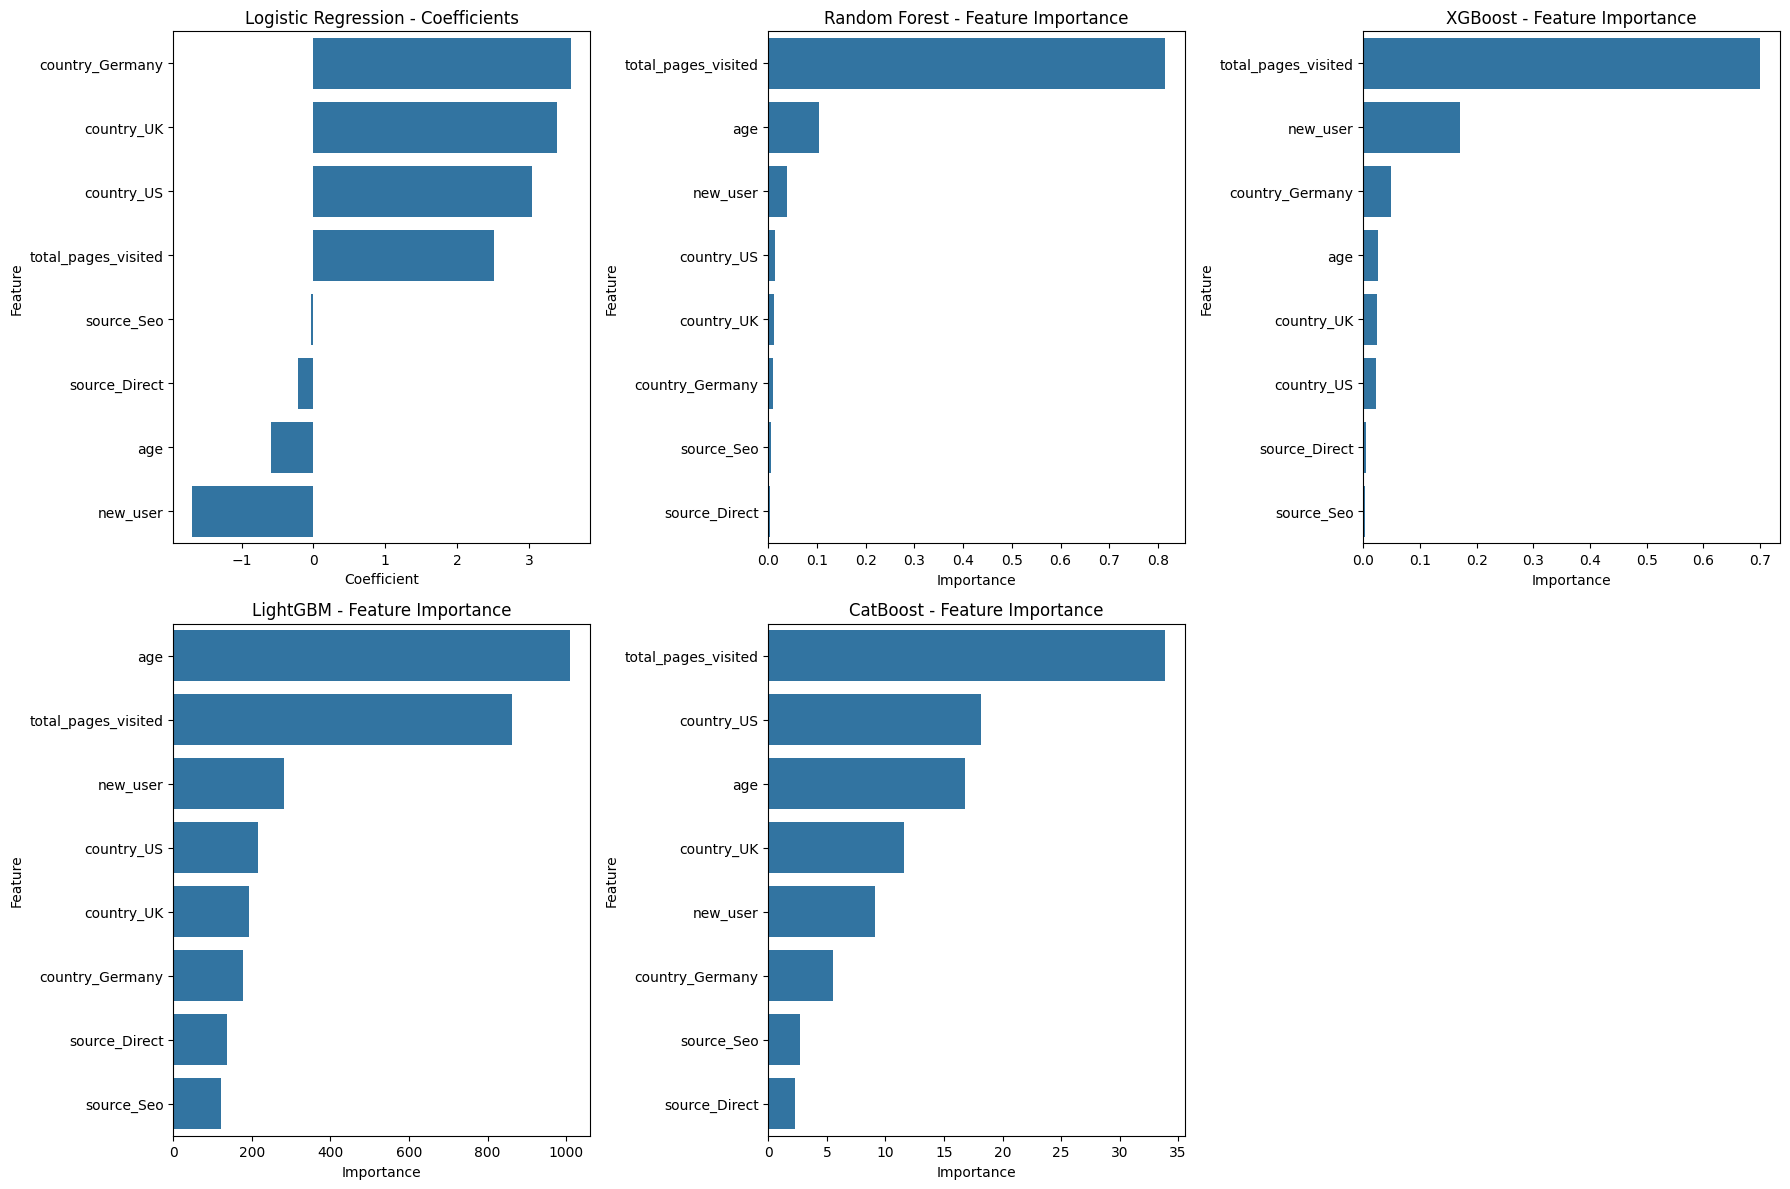

In [135]:
# Dictionnaire pour stocker importances
importances = {}

# Logistic Regression
importances['LogisticRegression'] = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

# Random Forest
importances['RandomForest'] = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# XGBoost
importances['XGBoost'] = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# LightGBM
importances['LightGBM'] = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# CatBoost
importances['CatBoost'] = pd.DataFrame({
    'Feature': X.columns,
    'Importance': cat_model.feature_importances_
}).sort_values(by='Importance', ascending=False)



# Visualisation des importances des features
plt.figure(figsize=(18, 12))

# Logistic Regression
plt.subplot(2,3,1)
sns.barplot(x='Coefficient', y='Feature', data=importances['LogisticRegression'])
plt.title("Logistic Regression - Coefficients")

# Random Forest
plt.subplot(2,3,2)
sns.barplot(x='Importance', y='Feature', data=importances['RandomForest'])
plt.title("Random Forest - Feature Importance")

# XGBoost
plt.subplot(2,3,3)
sns.barplot(x='Importance', y='Feature', data=importances['XGBoost'])
plt.title("XGBoost - Feature Importance")

# LightGBM
plt.subplot(2,3,4)
sns.barplot(x='Importance', y='Feature', data=importances['LightGBM'])
plt.title("LightGBM - Feature Importance")

# CatBoost
plt.subplot(2,3,5)
sns.barplot(x='Importance', y='Feature', data=importances['CatBoost'])
plt.title("CatBoost - Feature Importance")

plt.tight_layout()
plt.show()


                Model  F1-score   ROC-AUC
0  LogisticRegression  0.781786  0.988544
1            LightGBM  0.781465  0.987734
2             XGBoost  0.772650  0.987164
3            CatBoost  0.771098  0.987588
4        RandomForest  0.745184  0.955640


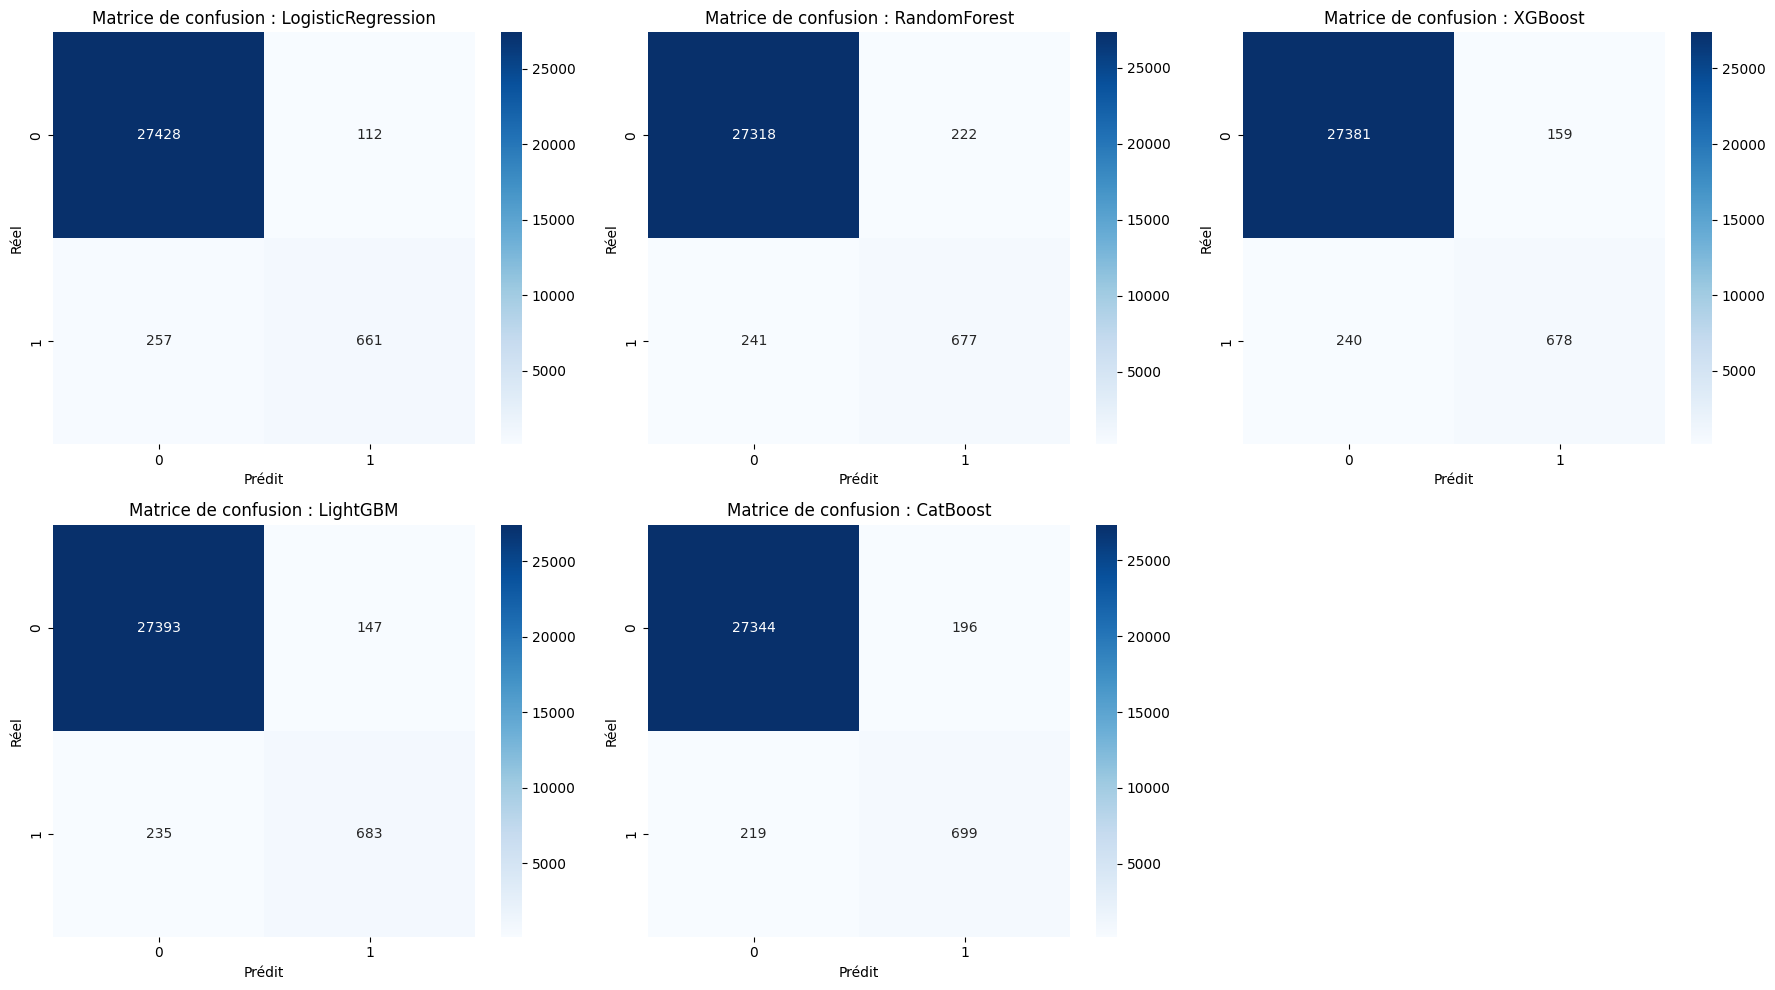

In [136]:
# Comparaison F1-score / ROC-AUC
metrics_df = pd.DataFrame({
    'Model': list(f1_scores.keys()),
    'F1-score': list(f1_scores.values()),
    'ROC-AUC': [roc_scores[name] for name in f1_scores.keys()]
}).sort_values(by='F1-score', ascending=False).reset_index(drop=True)

print(metrics_df)

# Matrices de confusion
fig, axes = plt.subplots(2, 3, figsize=(18,10))  # 2 lignes, 3 colonnes -> 6 axes
axes = axes.ravel()  # pour accéder facilement avec axes[i]

for i, (name, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"Matrice de confusion : {name}")
    axes[i].set_xlabel("Prédit")
    axes[i].set_ylabel("Réel")

# Supprimer les axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [137]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    estimator=LGBMClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best F1:", grid.best_score_)

[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=2. Current value: min_data_in_leaf=2
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=2. Current value: min_data_in_leaf=2
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Number of positive: 8262, number of negative: 247860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001615 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 95
[LightGBM] [Info] Number of data points in the train set: 256122, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032258 -> initscore=-3.401197
[LightGBM] [Info] Start training from score -3.401197
[LightGBM] [Warning] No further 

## Interpréation des modèles et choix du modèle le plus performant

Différences entre les modèles : 
 - Régression logistique : modèle linéaire. Les coefficients indiquent l’impact linéaire de chaque variable sur la probabilité de conversion. Les variables fortement corrélées peuvent voir leurs coefficients « dilués » ou compensés par d’autres features.

_Exemple_ : un coefficient positif pour country_Germany signifie que, toutes choses égales par ailleurs, être en Allemagne augmente la probabilité de conversion. 

- LightGBM (gradient boosting) et autres modèles : modèle non linéaire basé sur des arbres. L’importance des features reflète combien chaque variable a contribué à réduire l’impureté ou l’erreur dans les arbres.

_Exemple_: Age peut ressortir comme plus important même si, linéairement, son effet est faible, parce que des interactions non linéaires entre âge et autres variables sont prises en compte.

### Interprétation de la regression logistique
#### Features positives (augmentent la probabilité de conversion)
* Les utilisateurs venant d’Allemagne ont beaucoup plus de chances de convertir que la référence (China).
* Plus un utilisateur visite de pages, plus il a de chances de s’abonner. Chaque écart-type supplémentaire multiplie les chance de conversion.

#### Features négatives (réduisent la probabilité de conversion)
* Les nouveaux utilisateurs sont moins susceptibles de convertir. → Possible levier : les cibler avec des messages d’incitation.
* Les utilisateurs plus âgés ont légèrement moins de chances de convertir.
* Les utilisateurs arrivant par accès direct convertissent un peu moins que la référence (ads).
* Impact très faible, quasiment neutre pour Source_seo

### Interprétation des arbres de décision
* age = plus un utilisateur est dans la moyenne (31 ans), plus il aura de chance de souscrite à un abonnement de type newsletter.
* total_pages_visited = Plus un utilisateur visite de pages, plus il a de chances de convertir.
* les features "new_user", "country_*", "source_*" n'ont pas d'impact significatif sur la conversion 

Différences entre modèles :
- La régression logistique met en avant les effets des pays (coefficients très positifs).
- Random Forest voit ces features comme moins importantes car le nombre de pages visitées domine les décisions dans les arbres.

### Choix du modèle
- LightGBM est légèrement meilleur sur ton dataset (F1 = 0.7673).
- XGBoost et CatBoost sont très proches derrière, donc également de bons choix.
- RandomForest est correct mais un peu moins performant que les gradient boosting.
- DecisionTree simple est le moins performant (risque de surapprentissage et de variance élevée).

### Interpréation
_F1-score_ : 
Définition : F1-score = 2 × (Précision × Rappel) / (Précision + Rappel)
Précision (Precision) : parmi les utilisateurs prédits convertis, combien le sont réellement
Rappel (Recall) : parmi les utilisateurs réellement convertis, combien ont été prédits convertis

_ROC-AUC_ : 
Définition : Aire sous la courbe ROC (True Positive Rate vs False Positive Rate)
ROC-AUC proche de 1 → le modèle sépare très bien les convertis des non-convertis

_Matrices de confusion_
Permet de voir vraies et fausses prédictions :

|-|Prédit Non | Prédit Oui |
|---------|------------------------|
|Réel Non | TN        | FP         |
|Réel Oui | FN     	  | TP         |

TN = utilisateur non converti correctement prédit
FP = utilisateur non converti prédit converti (faux positif)
FN = utilisateur converti prédit non converti (faux négatif)
TP = utilisateur converti correctement prédit

Dans un contexte de conversion rare (~3%), il est normal d’avoir beaucoup de TN.

L’objectif est de maximiser TP sans trop augmenter FP → F1-score mesure ce compromis.

Comparaison des modèles d'arbres de décision : 
- LightGBM	: Meilleur équilibre précision/rappel, sépare bien convertis/non-convertis
- XGBoost	 : Très proche de LightGBM
- CatBoost : Bonne performance globale
- RandomForest : Légèrement moins performant
LightGBM est le meilleur modèle sur cet ensemble de données
On peut utiliser ses importances de features pour identifier les leviers d’action (pages visitées, pays, âge, source…)

## Modèle

In [139]:
# Préparation des features et de la cible
features_list = [
    'total_pages_visited', 'age', 'new_user',
    'country_Germany', 'country_UK', 'country_US',
    'source_Direct', 'source_Seo'
]

X_full = dataset_encoded[features_list].copy()  # DataFrame complet
y_full = dataset_encoded['converted']

# Standardisation des variables numériques
num_features = ['total_pages_visited', 'age']
scaler = StandardScaler()
X_full[num_features] = scaler.fit_transform(X_full[num_features])

# Réentraînement LightGBM sur tout le dataset
best_model = LGBMClassifier(random_state=42, n_estimators=100)
best_model.fit(X_full, y_full)
print("Réentraînement terminé sur tout le dataset.")
print(best_model)

# Préparation du dataset test
data_test = pd.read_csv('conversion_data_test.csv')

# OneHot encoder country et source
data_test_encoded = pd.get_dummies(data_test, columns=['country', 'source'])

# Colonnes attendues par le modèle
expected_cols = [
    'total_pages_visited', 'age', 'new_user',
    'country_Germany', 'country_UK', 'country_US',
    'source_Direct', 'source_Seo'
]

# Ajouter les colonnes manquantes avec des zéros
for col in expected_cols:
    if col not in data_test_encoded.columns:
        data_test_encoded[col] = 0

# Réordonner les colonnes exactement comme dans le modèle
data_test_encoded = data_test_encoded[expected_cols]

# Standardisation des variables numériques
num_features = ['total_pages_visited', 'age']
data_test_encoded[num_features] = scaler.transform(data_test_encoded[num_features])

# Prédictions

predictions = best_model.predict(data_test_encoded)

# Export CSV
submission = pd.DataFrame({'converted': predictions})
submission.to_csv('conversion_data_test_predictions_LefortNadege-LightGBM.csv', index=False)

print("Prédictions générées et fichier CSV exporté.")


[LightGBM] [Info] Number of positive: 9180, number of negative: 275400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000870 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 96
[LightGBM] [Info] Number of data points in the train set: 284580, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032258 -> initscore=-3.401197
[LightGBM] [Info] Start training from score -3.401197
Réentraînement terminé sur tout le dataset.
LGBMClassifier(random_state=42)
Prédictions générées et fichier CSV exporté.


## Actions concrètes
- dans un premier temps : cibler les jeunes, les encourager à visiter plus de pages
- aller chercher de nouveaux utilisateurs pour qu'ils viennent visiter le site

campagne d'action et de publiciré sur sur les réseaux sociaux,
renforcement du référencement naturel sur le web,
partenariats avec les écoles,
